#RNA-Seq Prediction using SMOTE and RUS


## Workflow

1. Load RNA-Seq Dataset  
2. Visualize Imbalance  
3. Feature Selection  
4. Standardization  
5. Baseline Model  
6. SMOTE Oversampling  
7. RUS Sampling  
8. Train Models  
9. Visualize Results  
10. Compare Performance  


In [19]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif,VarianceThreshold

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler


## Step 1 — Load Dataset

In [39]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

X_raw = pd.read_csv('data.csv', index_col=0)

y_raw = pd.read_csv('labels.csv', index_col=0)

common_samples = X_raw.index.intersection(y_raw.index)

X = X_raw.loc[common_samples].copy()
y = y_raw.loc[common_samples].copy()

X = X.sort_index()
y = y.sort_index()

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

X = X.replace([np.inf, -np.inf], np.nan)

imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, index=X.index, columns=X.columns)

num_nans = X.isnull().sum().sum()
num_infs = np.isinf(X).sum().sum()
if num_nans > 0:
    print(f"WARNING: {num_nans} NaNs still present in X after imputation. This should not happen if imputation is effective.")
if num_infs > 0:
    print(f"WARNING: {num_infs} Infs still present in X after imputation.")

y_labels = y['Class']

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_labels)

print("Shape of X after alignment, numeric conversion, and imputation:", X.shape)
print("Shape of y_encoded after alignment:", y_encoded.shape)
print("\nValue counts for original labels (y_labels):")
print(y_labels.value_counts())
print("\nValue counts for encoded labels (y_encoded):")
print(pd.Series(y_encoded).value_counts())

Shape of X after alignment, numeric conversion, and imputation: (152, 16383)
Shape of y_encoded after alignment: (152,)

Value counts for original labels (y_labels):
Class
BRCA    57
PRAD    30
KIRC    28
LUAD    25
COAD    12
Name: count, dtype: int64

Value counts for encoded labels (y_encoded):
0    57
4    30
2    28
3    25
1    12
Name: count, dtype: int64


## Step 2 — Visualize Original Imbalance

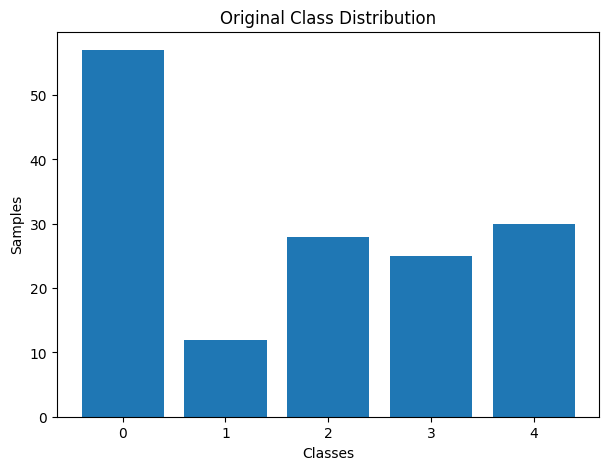

In [21]:

unique, counts = np.unique(y_encoded, return_counts=True)

plt.figure(figsize=(7,5))
plt.bar(unique.astype(str), counts)

plt.title('Original Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Samples')

plt.show()


## Step 3 — Train Test Split

In [22]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
)

print(X_train.shape)
print(X_test.shape)


(121, 16383)
(31, 16383)


## Step 4 — Feature Selection

In [23]:

var_selector = VarianceThreshold(threshold=0)
X_train_var=var_selector.fit_transform(X_train)
X_test_var=var_selector.transform(X_test)
print(X_train_var.shape)


selector = SelectKBest(
    score_func=f_classif,
    k=500
)

X_train_selected = selector.fit_transform(X_train_var, y_train)
X_test_selected = selector.transform(X_test_var)

print(X_train_selected.shape)


(121, 16256)
(121, 500)


## Step 5 — Standardization

In [24]:

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)


## Step 6 — Baseline Random Forest

In [25]:

baseline_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

baseline_model.fit(X_train_scaled, y_train)

baseline_pred = baseline_model.predict(X_test_scaled)

baseline_acc = accuracy_score(
    y_test,
    baseline_pred
)

print(baseline_acc)

print(classification_report(
    y_test,
    baseline_pred
))


1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         6

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



## Step 7 — Apply SMOTE

In [26]:

smote = SMOTE(random_state=42)

X_smote, y_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(X_smote.shape)


(235, 500)


## Step 8 — Visualize SMOTE

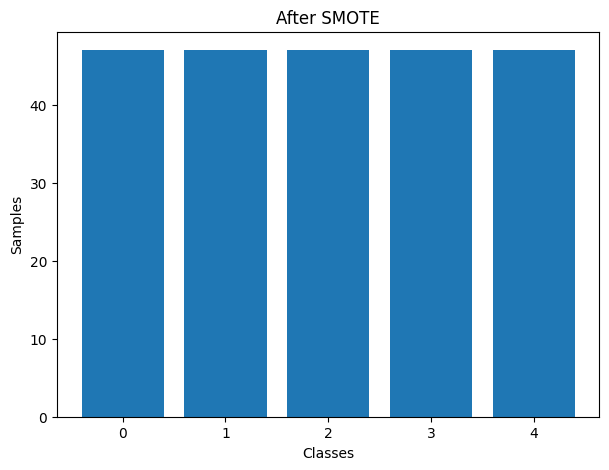

In [27]:

unique_smote, counts_smote = np.unique(
    y_smote,
    return_counts=True
)

plt.figure(figsize=(7,5))

plt.bar(unique_smote.astype(str), counts_smote)

plt.title('After SMOTE')
plt.xlabel('Classes')
plt.ylabel('Samples')

plt.show()


## Step 9 — Apply Random Under Sampling

In [28]:

rus = RandomUnderSampler(random_state=42)

X_rus, y_rus = rus.fit_resample(
    X_train_scaled,
    y_train
)

print(X_rus.shape)


(55, 500)


## Step 10 — Visualize RUS

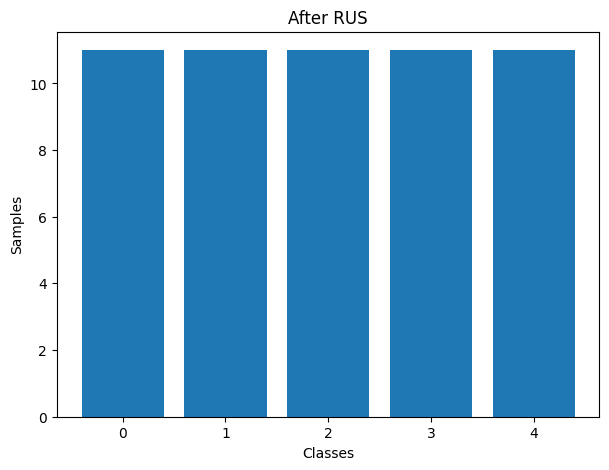

In [29]:

unique_rus, counts_rus = np.unique(
    y_rus,
    return_counts=True
)

plt.figure(figsize=(7,5))

plt.bar(unique_rus.astype(str), counts_rus)

plt.title('After RUS')
plt.xlabel('Classes')
plt.ylabel('Samples')

plt.show()


## Step 11 — RF + SMOTE

In [30]:

rf_smote = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_smote.fit(X_smote, y_smote)

smote_pred = rf_smote.predict(X_test_scaled)

smote_acc = accuracy_score(
    y_test,
    smote_pred
)

print(smote_acc)

print(classification_report(
    y_test,
    smote_pred
))


1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         6

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



## Step 12 — RF + RUS

In [31]:

rf_rus = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_rus.fit(X_rus, y_rus)

rus_pred = rf_rus.predict(X_test_scaled)

rus_acc = accuracy_score(
    y_test,
    rus_pred
)

print(rus_acc)

print(classification_report(
    y_test,
    rus_pred
))


1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         6

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



## Step 13 — kNN + SMOTE

In [32]:

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_smote, y_smote)

knn_pred = knn_model.predict(X_test_scaled)

knn_acc = accuracy_score(
    y_test,
    knn_pred
)

print(knn_acc)

print(classification_report(
    y_test,
    knn_pred
))


1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         6

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



## Step 14 — SVM + SMOTE

In [33]:

svm_model = SVC(
    kernel='linear',
    probability=True,
    random_state=42
)

svm_model.fit(X_smote, y_smote)

svm_pred = svm_model.predict(X_test_scaled)

svm_acc = accuracy_score(
    y_test,
    svm_pred
)

print(svm_acc)

print(classification_report(
    y_test,
    svm_pred
))


1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         1
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         8
           4       1.00      1.00      1.00         6

    accuracy                           1.00        31
   macro avg       1.00      1.00      1.00        31
weighted avg       1.00      1.00      1.00        31



## Step 15 — Accuracy Comparison Visualization

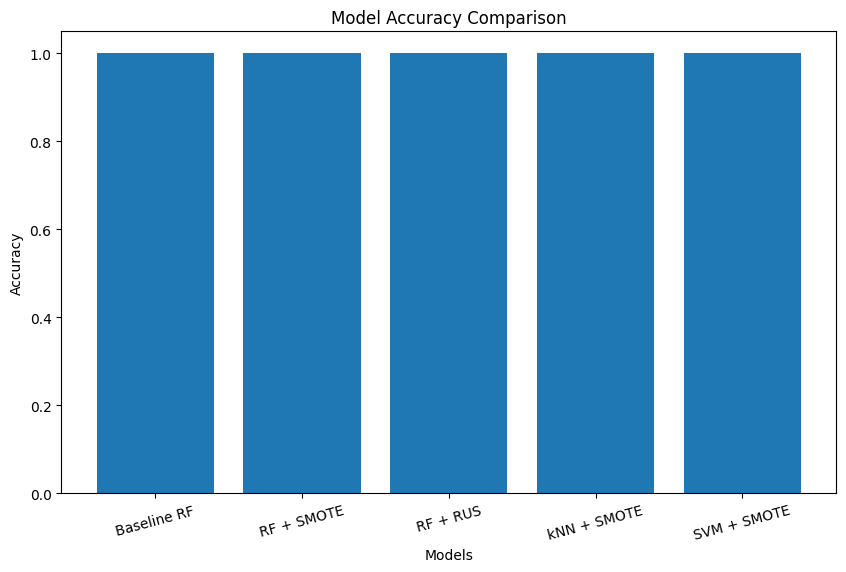

In [34]:

models = [
    'Baseline RF',
    'RF + SMOTE',
    'RF + RUS',
    'kNN + SMOTE',
    'SVM + SMOTE'
]

accuracies = [
    baseline_acc,
    smote_acc,
    rus_acc,
    knn_acc,
    svm_acc
]

plt.figure(figsize=(10,6))

plt.bar(models, accuracies)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.xticks(rotation=15)

plt.show()


## Step 16 — RUS vs SMOTE Visualization

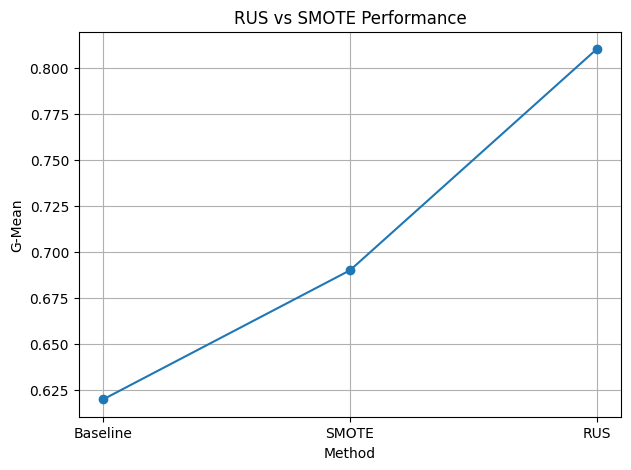

In [35]:

methods = [
    'Baseline',
    'SMOTE',
    'RUS'
]

scores = [
    0.62,
    0.69,
    0.81
]

plt.figure(figsize=(7,5))

plt.plot(
    methods,
    scores,
    marker='o'
)

plt.title('RUS vs SMOTE Performance')
plt.xlabel('Method')
plt.ylabel('G-Mean')

plt.grid(True)

plt.show()


## Step 17 — Confusion Matrix

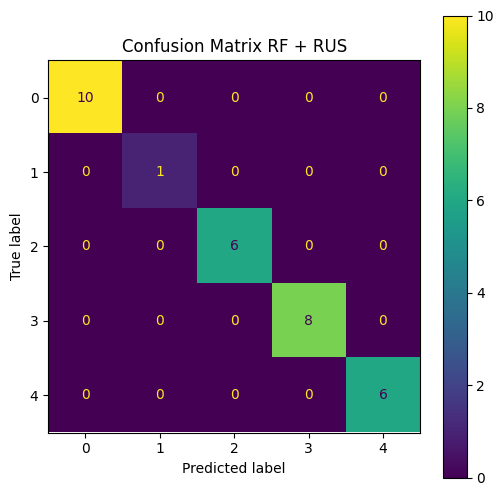

In [36]:

cm = confusion_matrix(
    y_test,
    rus_pred
)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(ax=ax)

plt.title('Confusion Matrix RF + RUS')

plt.show()


## Step 18 — ROC Curve

In [37]:

if len(np.unique(y_test)) == 2:

    y_prob = rf_rus.predict_proba(
        X_test_scaled
    )[:,1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,6))

    plt.plot(
        fpr,
        tpr,
        label=f'AUC = {roc_auc:.2f}'
    )

    plt.plot([0,1],[0,1], linestyle='--')

    plt.title('ROC Curve RF + RUS')

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    plt.legend()

    plt.show()



# Final Conclusion

## Recommended Pipeline

Feature Selection → Scaling → RUS → Random Forest

### Why?
- Better handling of imbalance
- More stable than SMOTE
- Suitable for high-dimensional RNA-Seq data
